# Embeddings para recuperación en español

Comparación de cuatro modelos con búsqueda restringida al manual correcto.

Este notebook solo lee resultados guardados. Ejecutar todas las celdas no descarga modelos, no consulta servicios y no sobrescribe las mediciones.

## Método y alcance

El corpus sintético contiene 36 pasajes y 24 consultas. La velocidad se mide sobre 100 documentos. El diagnóstico simétrico usa cinco pares similares y cinco distintos. E5 distingue consultas y pasajes mediante sus prefijos. R@k indica la proporción de consultas con algún pasaje válido entre los primeros k. MRR@10 mide el inverso del rango del primer pasaje válido.

Solo se conserva la tabla agregada original. `results.json` es su transcripción, no un registro de predicciones por consulta. El notebook antiguo guardaba un error de dependencia. Eso impide acreditar su ejecución completa a partir de sus celdas.

In [1]:
import json
import sys
from pathlib import Path


sys.dont_write_bytecode = True


YELLOW = "\033[33m"


CYAN = "\033[36m"


GREEN = "\033[32m"


RESET = "\033[0m"


PALETTE = (
    "#89b4fa",
    "#cba6f7",
    "#f38ba8",
    "#b4befe",
    "#fab387",
    "#a6e3a1",
    "#f9e2af",
    "#94e2d5",
    "#74c7ec",
    "#eba0ac",
)


def info(text: str, highlight: object = "", after: str = "") -> None:
    """Resalta un dato y devuelve el resto del mensaje al cian."""
    message = text.rstrip(". ")
    if highlight != "":
        message += f" {GREEN}{highlight}{CYAN}"
    if after:
        message += f" {after.rstrip('. ')}"
    print(f"{YELLOW}[*]{RESET} {CYAN}{message}.{RESET}")


def read_json(path: Path) -> dict:
    with path.open(encoding="utf-8-sig") as stream:
        return json.load(stream)


def markdown_table(rows: list[dict], columns: dict[str, str]) -> str:
    from tabulate import tabulate

    return tabulate(
        [
            [
                f"{row[key]:.4f}".rstrip("0").rstrip(".")
                if isinstance(row[key], float)
                else row[key]
                for key in columns
            ]
            for row in rows
        ],
        headers=list(columns.values()),
        tablefmt="github",
        disable_numparse=True,
    )


def show_table(rows: list[dict], columns: dict[str, str]) -> None:
    from IPython.display import Markdown, display

    display(Markdown(markdown_table(rows, columns)))


def plot_metrics(rows: list[dict], metrics: list[tuple[str, str]], title: str):
    """Dos paneles horizontales para conservar etiquetas legibles."""
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    style = {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.titlepad": 14,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False,
        "axes.edgecolor": "#bcc2cc",
        "axes.labelcolor": "#414654",
        "xtick.color": "#565e6d",
        "ytick.color": "#252a34",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "svg.fonttype": "none",
    }
    with mpl.rc_context(style):
        height = max(3.7, len(rows) * 0.42 + 1.4)
        figure, axes = plt.subplots(
            1,
            len(metrics),
            figsize=(13, height),
            layout="constrained",
            squeeze=False,
            sharey=True,
        )
        labels = [str(row["label"]) for row in rows]
        colors = [row.get("color", PALETTE[index % len(PALETTE)]) for index, row in enumerate(rows)]
        for axis, (key, caption) in zip(axes[0], metrics, strict=True):
            values = [row[key] for row in rows]
            bars = axis.barh(range(len(labels)), values, color=colors, height=0.64, zorder=3)
            axis.set_yticks(range(len(labels)), labels)
            axis.set_title(caption, loc="left")
            axis.set_axisbelow(True)
            axis.grid(axis="x", color="#e9ebef", linewidth=0.8)
            axis.tick_params(axis="y", length=0, pad=8)
            axis.margins(x=0.2)
            axis.bar_label(
                bars,
                labels=[f"{value:.3f}".rstrip("0").rstrip(".") for value in values],
                padding=5,
                fontsize=9,
            )
        axes[0, 0].set_ylim(len(labels) - 0.5, -0.5)
        figure.suptitle(title, fontsize=15, weight="bold", color="#252a34")
    plt.close(figure)
    return figure


relative = Path("rag/embeddings")
here = Path.cwd().resolve()
benchmarks = next(
    parent / "docs/benchmarks"
    for parent in (here, *here.parents)
    if (parent / "docs/benchmarks" / relative / "results.json").is_file()
)

study = benchmarks / relative
data = read_json(study / "results.json")
info("Resultados guardados de", relative.as_posix(), "cargados")

rows = data["summary"]

[*] Resultados guardados de rag/embeddings cargados.


## Resultados

Los JSON conservan las mediciones originales.

### Recuperación

In [2]:
show_table(
    rows,
    {
        "label": "Modelo",
        "dimensions": "Dim.",
        "recall1": "R@1 ↑",
        "recall3": "R@3 ↑",
        "mrr10": "MRR@10 ↑",
    },
)

| Modelo                                | Dim.   | R@1 ↑   | R@3 ↑   | MRR@10 ↑   |
|---------------------------------------|--------|---------|---------|------------|
| multilingual-e5-small                 | 384    | 0.9583  | 0.9583  | 0.9688     |
| multilingual-e5-base                  | 768    | 0.9167  | 0.9583  | 0.9479     |
| paraphrase-multilingual-MiniLM-L12-v2 | 384    | 0.8333  | 0.9583  | 0.901      |
| all-MiniLM-L6-v2                      | 384    | 0.625   | 0.875   | 0.7435     |

### Coste y diagnóstico

In [3]:
show_table(
    rows,
    {
        "label": "Modelo",
        "load_s": "Carga s",
        "ram_mb": "RAM MB",
        "ms_document": "ms/doc",
        "delta_symmetric": "Δ sim.",
        "delta_asymmetric": "Δ asim.",
    },
)

| Modelo                                | Carga s   | RAM MB   | ms/doc   | Δ sim.   | Δ asim.   |
|---------------------------------------|-----------|----------|----------|----------|-----------|
| multilingual-e5-small                 | 3.68      | 303.5    | 1.92     | 0.0998   | 0.0281    |
| multilingual-e5-base                  | 3.53      | 291.4    | 7.24     | 0.1039   | 0.0332    |
| paraphrase-multilingual-MiniLM-L12-v2 | 3.41      | 314.2    | 1.99     | 0.4877   | 0.0973    |
| all-MiniLM-L6-v2                      | 5.56      | 371.8    | 1.25     | 0.1523   | 0.0229    |

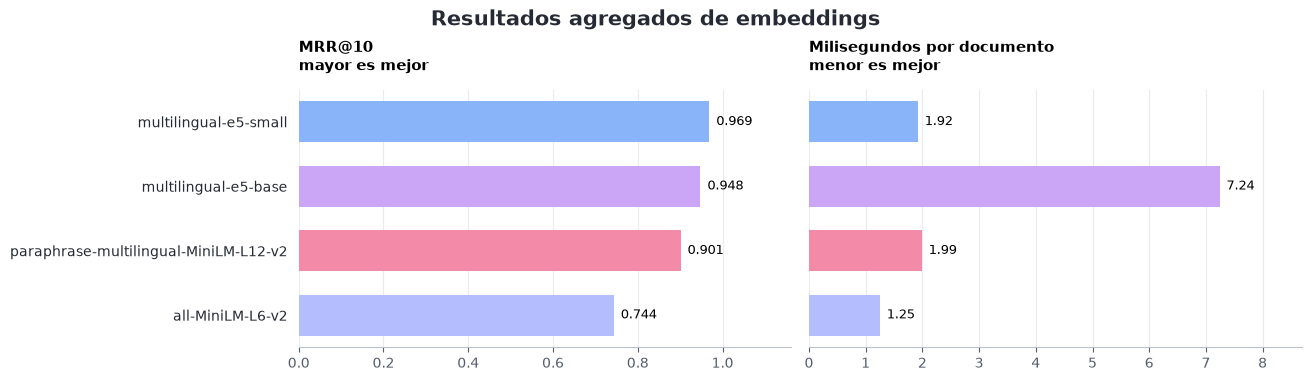

In [4]:
figure_0 = plot_metrics(
    rows,
    [
        ("mrr10", "MRR@10\nmayor es mejor"),
        ("ms_document", "Milisegundos por documento\nmenor es mejor"),
    ],
    "Resultados agregados de embeddings",
)
figure_0

## Conclusiones

`multilingual-e5-small` ofrece el mejor resultado según el criterio del estudio.
Encuentra un fragmento válido entre los tres primeros en 23 de 24 consultas y
tarda 1,92 ms por documento.

Solo se conservan las cifras agregadas de un corpus sintético pequeño. Sirven
para elegir un candidato, pero no para asegurar el mismo resultado con manuales
reales ni recalcular el rendimiento de cada consulta.

## Archivos y reproducción

`measure.py` conserva el método de medición y requiere una ejecución explícita con un directorio nuevo. Consulta el [índice](../../README.md) antes de medir. Las dependencias actuales no garantizan repetir exactamente el entorno histórico ni sus tiempos.